# EvoCA 

EvoCA = Evolutionary Cellular Automata: a spatially inhomogeneous binary 2D CA where every cell is regarded as an organism, carrying a genome governing its local rule.  This model may be thought as an offshoot or evolution of GeneLife [1,2].

EvoCA has the following structure:

- **Life and death:**  In EvoCA, the life or death of a cell determined by a binary spatial variable, distinct from the local CA state.  Every live cell has an operative genome, regardless of its local CA state.
  - *Contrast with GeneLife*: In GeneLife the living state, with associated genome, is equated with the local cell state 1 (in accordance Conway's original analogy); a local state of zero is equated with death, and accordingly with an absence of genome.
- **Genome:** GeneLife has a genome for every living cell, and the genome determines the local dynamics of that cell.  GeneLife has a rich array of possible local rule spaces available.  EvoCA also has each live cell's local dynamics determined by a genome.  The space of local rules is more specific; the local rule is an LUT indexed by $(s_x,s_1,s_2,s_3)$, where $s_x$ is the CA state at position $x$, and $s_i$ are the sums over neighborhoods of increasing distance from $x$:
    ```
             3  
         2   1   2  
     3   1   X   1   3
         2   1   2  
             3 
             
    ```

    It turns out that the number of local configurations so specified results in a 250-bit LUT. See [model documentation](Docs/model.md) for details.

    In addition, the EvoCA organisms have a separate genome used in their eating process, described below.
- **Resource:**  EvoCA has a "food" resource that exists in the environment as a spatial field, and also within each organism, which feeds each time step by transferring a mouthful of food from the environment to its private store.  Since the spatial location of each organism is fixed, the food private to organism may be considered as a second spatial field.
- **Metabolism:** All live organisms of EvoCA are subject to a fixed resource tax every time step, decrementing their private food. Organisms eat food from the environment, and their ability to eat is determined by a local match between the local environment (on a 5x5 patch) and a private local spatial pattern that is genetically determined, and subject to mutation upon reproduction.  The pattern-matching algorithm represents the cell's ability to digest the food available in the environment.
- **Birth and death:**  GeneLife birth and death is determined by local dynamics governing transition between 1 (alive) and 0 (dead) states.  Reproduction happens when a cell's local state goes from 0 to 1, and a parent is chosen for inheretance of genetic information.  EvoCA life and death is determined by the resource private to an organism.  When a cell's private resource goes to zero, the organism associated with the cell dies, it's LUT genetic information is replaced with the LUT consisting of all zeros, and the life/death state variable at that cell's spatial location is set to zero (dead).  Birth happens when a cell's private resource reaches 1.0, in which case an offspring is placed in a neighbor location is chosen from the cell's Moore neighborhood, displacing the neighboring cell with lowest private resources (ties broken randomly).  Dead cells come alive only through a reproductive event.



[1.](./Docs/genelife-1.pdf) McCaskill, John S., and Norman H. Packard. "Analysing emergent dynamics of evolving computation in 2D cellular automata." In International Conference on Theory and Practice of Natural Computing, pp. 3-40. Cham: Springer International Publishing, 2019.

[2.](./Docs/genelife-2.pdf)  Packard, Norman H., and John S. McCaskill. "Open-endedness in genelife." Artificial Life 30.3 (2024): 356-389.

Tests the C core (ctypes), verifies exact GoL, and launches the SDL2 interactive display.

## 1  Build

In [1]:
import subprocess, sys, os
root = os.path.abspath('')
# macOS: gcc -dynamiclib; Linux: gcc -shared
import platform
flag = '-dynamiclib' if platform.system() == 'Darwin' else '-shared'
ext  = 'dylib'      if platform.system() == 'Darwin' else 'so'
cmd  = ['gcc', '-O2', '-Wall', '-fPIC', flag,
        '-o', f'C/libevoca.{ext}', 'C/evoca.c']
r = subprocess.run(cmd, cwd=root, capture_output=True, text=True)
print(r.stdout or '(no stdout)')
if r.returncode != 0:
    print('STDERR:', r.stderr, file=sys.stderr)
    raise RuntimeError('Build failed')
print('Build OK')

(no stdout)
Build OK


## 2  Imports

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(''))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
import time
from pprint import pprint

from python.evoca_py import EvoCA, make_gol_lut, LUT_BYTES, lut_bit_index
from python.evoca_py import unpack_lut, available_state_init
from python.display  import run as sdl_run
from python.controls import run_with_controls
from python.evoca_py import import_run
from python.controls import available_probes


## 3  Interactive display 

Uses ipywidgets controls + SDL2 window

Controls appear in the cell output below; simulation renders in a separate SDL2 window.

- **Pause / Run** — toggle simulation
- **Step** — single step while paused
- **Quit** — close SDL2 window and return
- **Sliders** — adjust metaparams live; simulation auto-pauses during drag and resumes after
- **Color** dropdown — switch between state / env-food / priv-food views
- SDL2 keyboard: `SPACE` pause · `C` colour · `S` step · `Q`/`Esc` quit

## Available probes

In [2]:
foo = available_probes()
pprint(foo)

{'activity': 'LUT genome activity (scrolling hash-colored strip)',
 'births': 'Mean +/- std of births array',
 'eg_activity': 'Egenome activity (scrolling hash-colored strip)',
 'eg_pop': 'Stacked area: egenome population fractions',
 'entropy': 'Local-pattern Shannon entropy',
 'env_food': 'Mean +/- std of environmental food F(x)',
 'lut_complexity': 'Stacked area: LUT ring-dependency level',
 'pat_activity': 'Local-pattern activity (scrolling hash-colored strip)',
 'priv_food': 'Mean +/- std of private food f(x)',
 'q_activity': 'Activity quantile profile (decile strip chart)'}


In [3]:
pprint(available_state_init())

{'F': "'uniform' (constant) | 'random' (uniform in F_range)",
 'F_init': "float: env food level when F='uniform'. Default 0.0",
 'F_range': "[lo, hi]: range when F='random'. Default [0.0, 1.0]",
 'alive': "'all' | 'fraction' | 'patch' | 'halfplane'",
 'alive_axis': "int 0|1: 0=left half, 1=top half (alive='halfplane'). Default "
               '0',
 'alive_fraction': "float 0-1: fraction alive (alive='fraction'). Default 0.5",
 'alive_radius': "int: half-side of central square (alive='patch'). Default 64",
 'egenome': "'uniform' (same value for all) | 'random' (random in 0..63)",
 'egenome_value': "int 0-63: egenome value when egenome='uniform'. Default 0",
 'f_init': 'float: initial private food per cell. Default 0.0',
 'lut': "'gol' (GoL rule for all) | 'random' (independent random LUT per cell)",
 'lut_n_init': 'int 1-3: ring depth for random LUT (1=10 bits, 2=50, 3=all '
               '250). Default 3',
 'v_density': 'float 0-1: fraction of cells with v=1. Default 0.5'}


In [4]:
gol_lut = make_gol_lut()

In [5]:
dict(N=256, food_inc=0.01, m_scale=1.0, mu_lut=0.0001)

{'N': 256, 'food_inc': 0.01, 'm_scale': 1.0, 'mu_lut': 0.0001}

In [6]:
N = 512
rng2 = np.random.default_rng(0)


#  1. Double m_scale: m_scale=0.4 (cells eat twice as fast → reach 1.0 in roughly the same time they reached 0.5 before)
#  2. Halve tax: tax=0.05 (cells survive longer → more time to accumulate)
#  3. Increase food_inc: food_inc=0.24 (more environmental food → faster eating)
#  4. Combination: e.g., m_scale=0.3, tax=0.07

params = {'N':N,
          'food_inc':0.12,
          'm_scale':0.4,
          'mu_lut':0.01,
          'mu_egene':0.01,
          'tax':0.05,
          'restricted_mu':False}
params_state = dict(lut='random', lut_n_init=1,
                  alive='fraction',
                  alive_fraction=0.5,
                  egenome='uniform',
                    egenome_value=0b000011,
                  f_init=0.1,
                  F_init=0.5)

probes = {'eg_pop': True,
          'eg_activity': True,
          'q_activity': True,
          'activity': True
         }
sim = EvoCA()
sim.init(**params)
sim.state(**params_state)
#sim.set_lut_all(gol_lut)
#sim.set_lut_random(n_init=1)
#sim.set_egenome_all(0b000011)
#sim.set_v(rng2.integers(0, 2, (N, N), dtype=np.uint8))
#sim.set_f_all(0.1)
#sim.set_F_all(0.5)

#run_with_controls(sim,paused=True)
#run_with_control(sim, paused=True, probes={'activity':True,'env_food': True, 'priv_food': True})
run_with_controls(sim, probes=probes)
#run_with_controls(sim, probes={'lut_complexity': True, 'activity': True},diag=True)
# Cell returns immediately.  Use widgets or Q/Esc in the SDL2 window to stop.

<Thread(evoca-sim, started daemon 6289747968)>

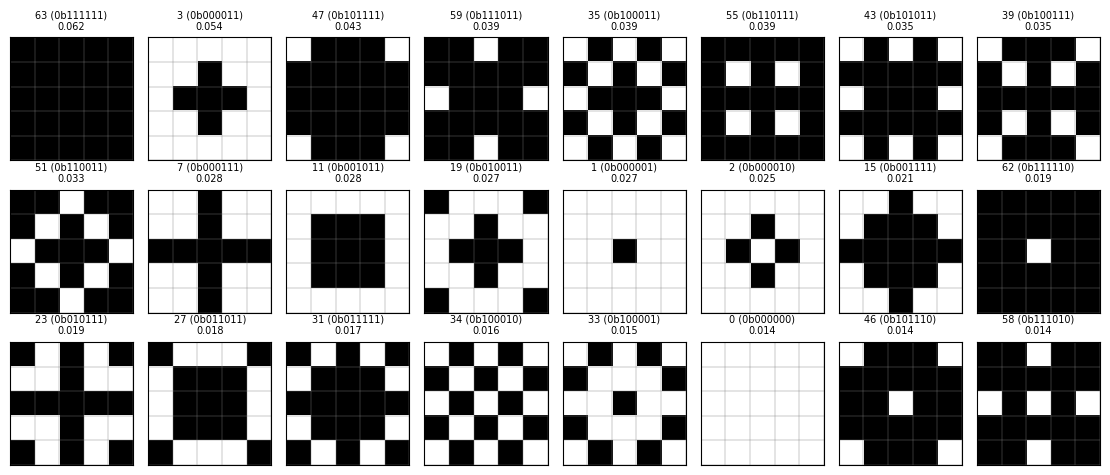

In [7]:
sim.plot_eg(24)


In [4]:
h = sim.get_repro_age_hist()

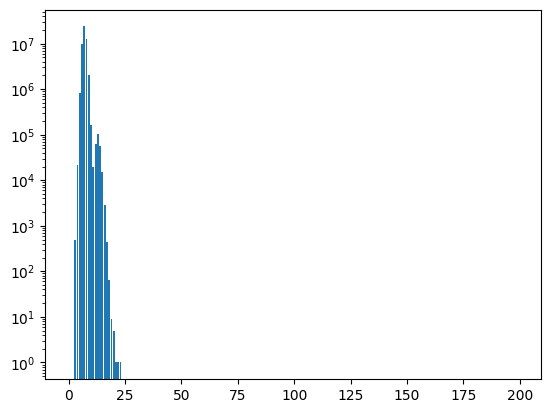

In [5]:
nn=200
plt.bar(range(nn),h[:nn]);
ax=plt.gca()
ax.set_yscale('log')

In [12]:
h[:60]

array([       0,        0,        0,        0,        0,        0,
              0,        0,        0,        0,        0,        0,
              0,        6,       56,      437,     3308,    21682,
         116215,   507114,  1724743,  4623166, 10280849, 25243811,
        6114602,  2359513,   806212,   223672,    57124,    12897,
           3141,      726,      293,       76,       64,        9,
             19,        7,       17,        3,        8,        0,
              3,       47,     4730,    65690,   149594,    30104,
              1,        0,        1,        0,        1,        0,
              0,        0,        1,        0,        0,        0],
      dtype=uint32)

In [32]:
foo=sim_sdl.get_lut(1)
len(foo)

32

In [33]:
foo

array([  0, 128,  15,   0, 248,   0,   4,  15,   4, 248,  64,  64,   1,
         1,  32,   8, 149, 255,   1, 232,  31, 144, 255,  65,  68,  31,
         2, 128,   4,   2,  12,   0], dtype=uint8)

In [22]:
food = sim_sdl.get_F()
len(food)

512

In [18]:
len(food)

0

In [13]:
import seaborn as sns

<Axes: ylabel='Density'>

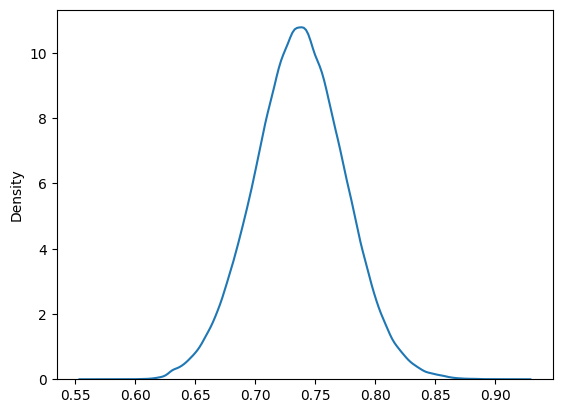

In [23]:
sns.kdeplot(data=food.flatten())

## 4  GoL-only SDL2 display  (food/repro disabled)

Use this to observe pure GoL dynamics with mutation=0.

In [ ]:
N = 512
rng3 = np.random.default_rng(7)

sim_gol = EvoCA()
sim_gol.init(N, food_inc=0.0, m_scale=0.0)
sim_gol.set_lut_all(gol_lut)
sim_gol.set_egenome_all(0)
sim_gol.set_v(rng3.integers(0, 2, (N, N), dtype=np.uint8))
sim_gol.set_f_all(0.0); sim_gol.set_F_all(0.0)

sdl_run(sim_gol)   # blocks until window closed
sim_gol.free()

# test import_run

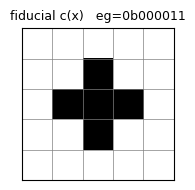

<Thread(evoca-sim, started daemon 6294237184)>

EvoCA SDL: starting  N=512 px=2  probes=['--lut-complexity=psm_341ea6e7']
EvoCA SDL: probe SharedMemory open failed: [Errno 2] No such file or directory: '/--activity=psm_14026cf2'
EvoCA SDL: activity shm opened (256x512)
EvoCA SDL: lut_complexity shm opened (128x512)
EvoCA SDL: SDL_Init OK
EvoCA SDL: window created and raised
EvoCA SDL: 0 probe window(s) created
EvoCA SDL: activity window created
EvoCA SDL: lut_complexity window created
EvoCA SDL: entering main loop


In [6]:
sim, kw = import_run('Runs/2026-03-16_2_branch_activity.evoca')

run_with_controls(sim,**kw)